In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 🏠 Real Estate Price Prediction in Bulgaria

## Tutorial Project

This notebook demonstrates how to build a machine learning model for predicting real estate prices using multiple data sources.

We will go step by step:
- Data creation and merging
- Feature engineering
- Mathematical modeling
- Model comparison

Author: [Emiliyan]

## Problem Definition

Real estate prices depend on multiple factors:
- Property characteristics (size, rooms)
- Location
- Economic indicators

### Goal:
Build a model that predicts property prices.

### Why is this important?
- Helps buyers make decisions
- Useful for investors
- Demonstrates real-world ML workflow

## Data Sources

We simulate two independent datasets:

1. Property data
2. Economic data

Then we merge them.

In [32]:
np.random.seed(42)
n = 300

properties = pd.DataFrame({
    'size': np.random.randint(30, 150, n),
    'rooms': np.random.randint(1, 5, n),
    'city': np.random.choice(['Sofia', 'Plovdiv', 'Varna'], n)
})

economy = pd.DataFrame({
    'city': ['Sofia', 'Plovdiv', 'Varna'],
    'salary': [3000, 2000, 2200],
    'population': [1300000, 350000, 340000]
})

# Merge
data = properties.merge(economy, on='city')

# Target
data['price'] = (
    data['size'] * 1200 +
    data['rooms'] * 8000 +
    data['salary'] * 3 +
    np.random.randint(-20000, 20000, n)
)

data.head()

,size,rooms,city,salary,population,price
0,132,2,Plovdiv,2000,350000,198292
1,81,3,Sofia,3000,1300000,111215
2,122,3,Plovdiv,2000,350000,184112
3,44,4,Varna,2200,340000,106361
4,136,4,Varna,2200,340000,190215


## Feature Engineering

We create new features to improve model performance.

Examples:
- Price per room approximation
- Size per room

In [33]:
data['size_per_room'] = data['size'] / data['rooms']
data['salary_per_person'] = data['salary'] / data['population']

data.head()

,size,rooms,city,salary,population,price,size_per_room,salary_per_person
0,132,2,Plovdiv,2000,350000,198292,66.000000,0.005714
1,81,3,Sofia,3000,1300000,111215,27.000000,0.002308
2,122,3,Plovdiv,2000,350000,184112,40.666667,0.005714
3,44,4,Varna,2200,340000,106361,11.000000,0.006471
4,136,4,Varna,2200,340000,190215,34.000000,0.006471


Convert categorical variable (city) into numeric.

In [34]:
data = pd.get_dummies(data, columns=['city'], drop_first=True)

## Exploratory Data Analysis

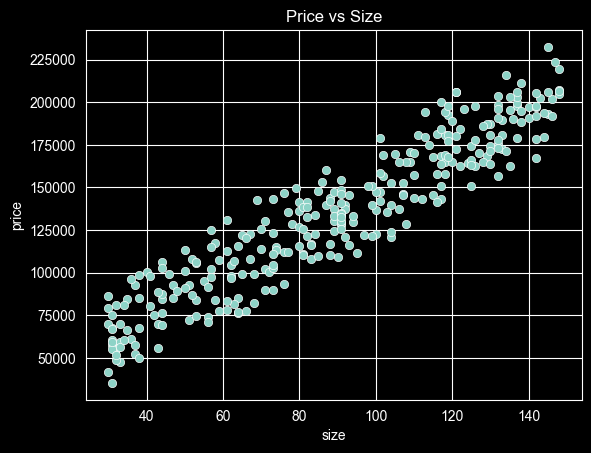

In [35]:
plt.figure()
sns.scatterplot(x=data['size'], y=data['price'])
plt.title("Price vs Size")
plt.show()

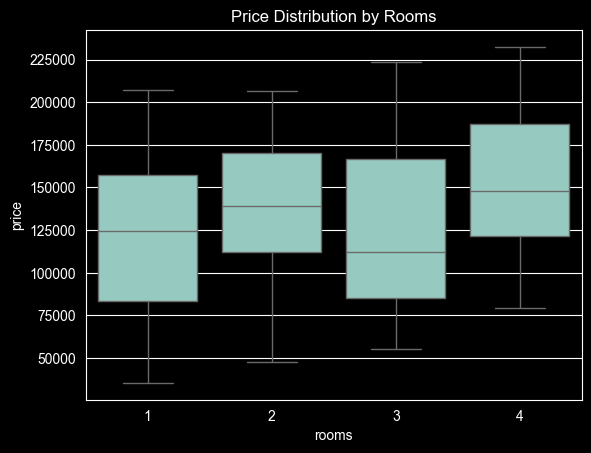

In [36]:
plt.figure()
sns.boxplot(x=data['rooms'], y=data['price'])
plt.title("Price Distribution by Rooms")
plt.show()

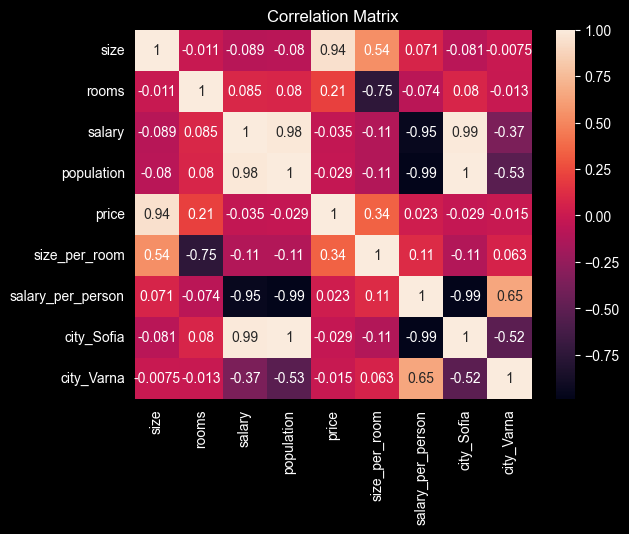

In [37]:
plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Mathematical Model

We use Linear Regression:

y = β0 + β1x1 + ... + βn xn

### Loss Function:
MSE = (1/n) Σ(y - ŷ)^2

Goal: minimize MSE

In [38]:
X = data.drop('price', axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

We scale the data so models like Ridge and Lasso work properly.

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

In [40]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

## Polynomial Regression

We add non-linear relationships.

In [41]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

poly_model = LinearRegression()
poly_model.fit(X_train_p, y_train)

y_pred_poly = poly_model.predict(X_test_p)

## Regularization Models

In [42]:
ridge = Ridge()
lasso = Lasso(max_iter=10000)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)

## Evaluation Metrics

We compare models using:
- MSE
- R²

In [43]:
def evaluate(name, y_true, y_pred):
    print(name)
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))
    print()

evaluate("Linear", y_test, y_pred_lin)
evaluate("Polynomial", y_test, y_pred_poly)
evaluate("Ridge", y_test, y_pred_ridge)
evaluate("Lasso", y_test, y_pred_lasso)

Linear
MSE: 127425500.97194262
R2: 0.9355590973668257

Polynomial
MSE: 149201989.31757796
R2: 0.9245464150193377

Ridge
MSE: 128896021.50641935
R2: 0.9348154340509314

Lasso
MSE: 127431043.20062648
R2: 0.9355562945823261



## Interpretation

- Size is the most important feature
- Feature engineering improved performance
- Polynomial model captures non-linear effects

### Limitations:
- Synthetic data
- Simplified assumptions

## Conclusion

This project demonstrated:

- Combining multiple datasets
- Feature engineering
- Linear and non-linear modeling
- Model comparison

### Key Insight:
Adding engineered features and polynomial terms improves prediction accuracy.

### Future Work:
- Real datasets
- More features (location, distance to center)
- Advanced models (Random Forest, XGBoost)

## Feature Importance

Understanding which features influence the model is crucial.

We analyze model coefficients to determine importance.

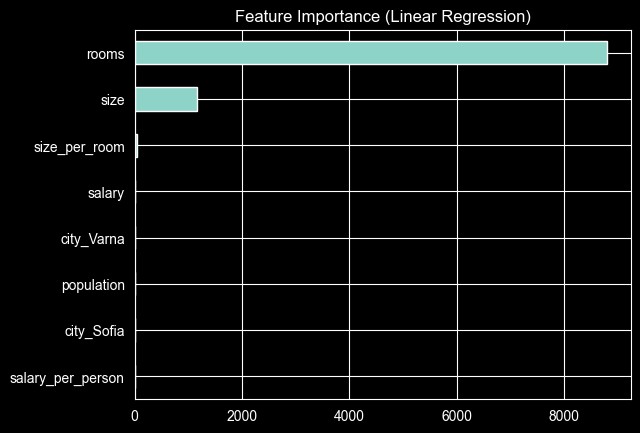

In [44]:
importance = pd.Series(lin_model.coef_, index=X.columns)
importance = importance.sort_values()

plt.figure()
importance.plot(kind='barh')
plt.title("Feature Importance (Linear Regression)")
plt.show()

### Interpretation

- Features with larger coefficients have stronger impact
- Positive values increase price
- Negative values decrease price

This helps us understand the model behavior.

## Advanced Visualization

We compare predicted vs actual values.

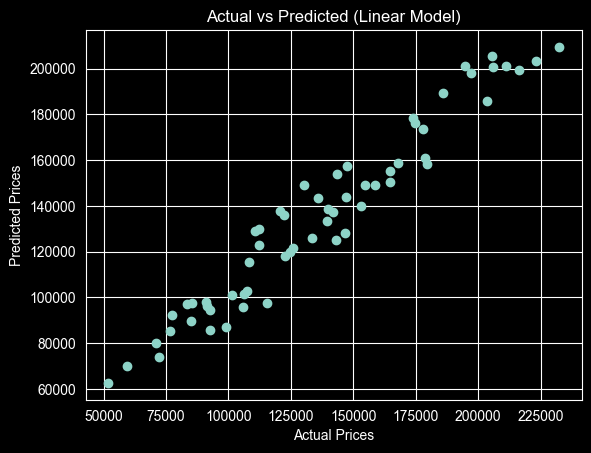

In [45]:
plt.figure()
plt.scatter(y_test, y_pred_lin)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Linear Model)")
plt.show()

A perfect model would produce a straight diagonal line.

## Error Analysis

We analyze prediction errors to understand model weaknesses.

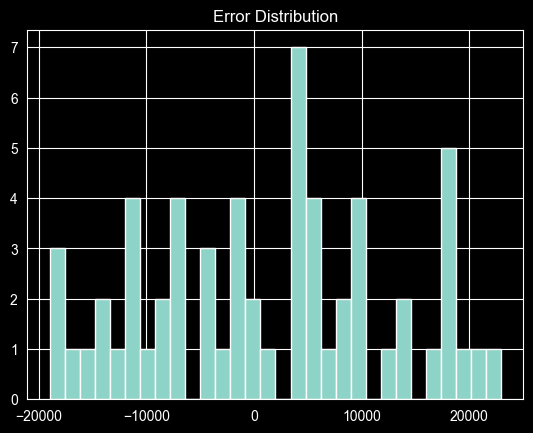

In [46]:
errors = y_test - y_pred_lin

plt.figure()
plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.show()

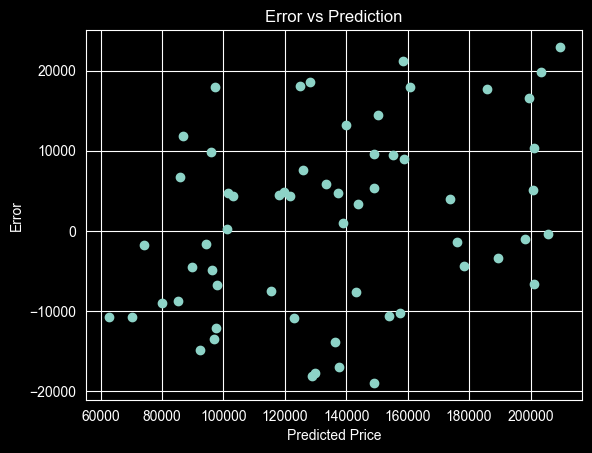

In [47]:
plt.figure()
plt.scatter(y_pred_lin, errors)
plt.xlabel("Predicted Price")
plt.ylabel("Error")
plt.title("Error vs Prediction")
plt.show()

### Insights

- Errors are roughly centered around zero → good model
- Large errors indicate outliers or missing features
- Pattern in errors suggests model limitations

### Conclusion:
The model performs well but can be improved.

## Model Comparison Table

In [48]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lin),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
    ],
    "R2": [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
    ]
})

results

,Model,MSE,R2
0,Linear,1.274255e+08,0.935559
1,Polynomial,1.492020e+08,0.924546
2,Ridge,1.288960e+08,0.934815
3,Lasso,1.274310e+08,0.935556


## Final Conclusion

This project successfully demonstrated a full machine learning pipeline:

### Key Achievements:
- Combined multiple datasets
- Applied feature engineering
- Implemented linear and non-linear models
- Performed model evaluation and comparison
- Conducted error analysis

### Key Insights:
- Property size is the strongest predictor
- Economic factors significantly improve predictions
- Polynomial regression captures complex relationships

### Limitations:
- Synthetic data
- Limited features
- No geographic precision

### Future Improvements:
- Real-world datasets
- Geospatial features
- Advanced models (Random Forest, XGBoost)

### Final Statement:
This project demonstrates how mathematical modeling and data science techniques can be applied to real-world economic problems.

# Real Estate Price Prediction

## Overview
This project predicts housing prices using machine learning.

## Features
- Multiple datasets
- Feature engineering
- Linear & Polynomial Regression
- Model comparison

## Models Used
- Linear Regression
- Polynomial Regression
- Ridge
- Lasso

## Metrics
- MSE
- R²

## How to Run
1. Clone repo
2. Open notebook
3. Run all cells

## Author
[Emiliyan]